In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
import os
print(os.getcwd())

C:\Users\practicanteit3\Documents\MBA\notebooks


In [3]:
df = pd.read_csv('../processed/vip_premium.csv', sep=';')
df_historial = pd.read_csv('../raw/ConsumoMasivoFiltro.csv', sep=';',low_memory=False)

In [4]:
df_historial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818543 entries, 0 to 3818542
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   factura              object 
 1   cliente              int64  
 2   nombrecliente        object 
 3   tipocliente          object 
 4   fechafactura         object 
 5   referencia           object 
 6   nombrereferencia     object 
 7   cantidad             float64
 8   preciounitario       float64
 9   costounitario        float64
 10  montoventa           float64
 11  montoventapesos      float64
 12  costoventapesos      float64
 13  valordescuento       float64
 14  unidadnegocios       int64  
 15  centrocostos         int64  
 16  troevendedor         float64
 17  troenombrevendedor   object 
 18  grouptat             object 
 19  lineatat             object 
 20  tro_e_marca          object 
 21  obsequio             int64  
 22  ruta                 float64
 23  porcentajedescuento  float64
 24

In [5]:
df.head()

,cliente,frecuencia,recencia,ticket_promedio,ticket,referencias_unicas,margen_promeido,margen,avg_descuento,cl_value,linea_favorita,marca_favorita
0,1592227,15,16,"185,303.44","5,003,192.99",9,"120,291.87","3,247,880.48",0.00,"2,779,551.66",MANGANESO,TRONEX
1,3358229,10,3,"310,117.69","4,031,529.99",4,"177,183.74","2,303,388.63",0.08,"3,101,176.92",MANGANESO,TRONEX
2,3364232,7,51,"118,953.76","1,070,583.87",5,"63,831.05","574,479.48",0.01,"832,676.34",BOMBILLAS,SB
3,3365883,15,59,"134,605.40","6,057,243.12",14,"74,874.77","3,369,364.53",0.02,"2,019,081.04",MANGANESO,TRONEX
4,3370696,7,9,"129,747.23","1,556,966.74",8,"74,147.21","889,766.56",0.00,"908,230.60",MANGANESO,TRONEX


## Escalado

In [6]:
X = df[['frecuencia','referencias_unicas','recencia']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Metodo del codo

C:\Users\practicanteit3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\practicanteit3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\practicanteit3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\practicanteit3\AppData\Local\anaconda3\Lib\site-packages\s

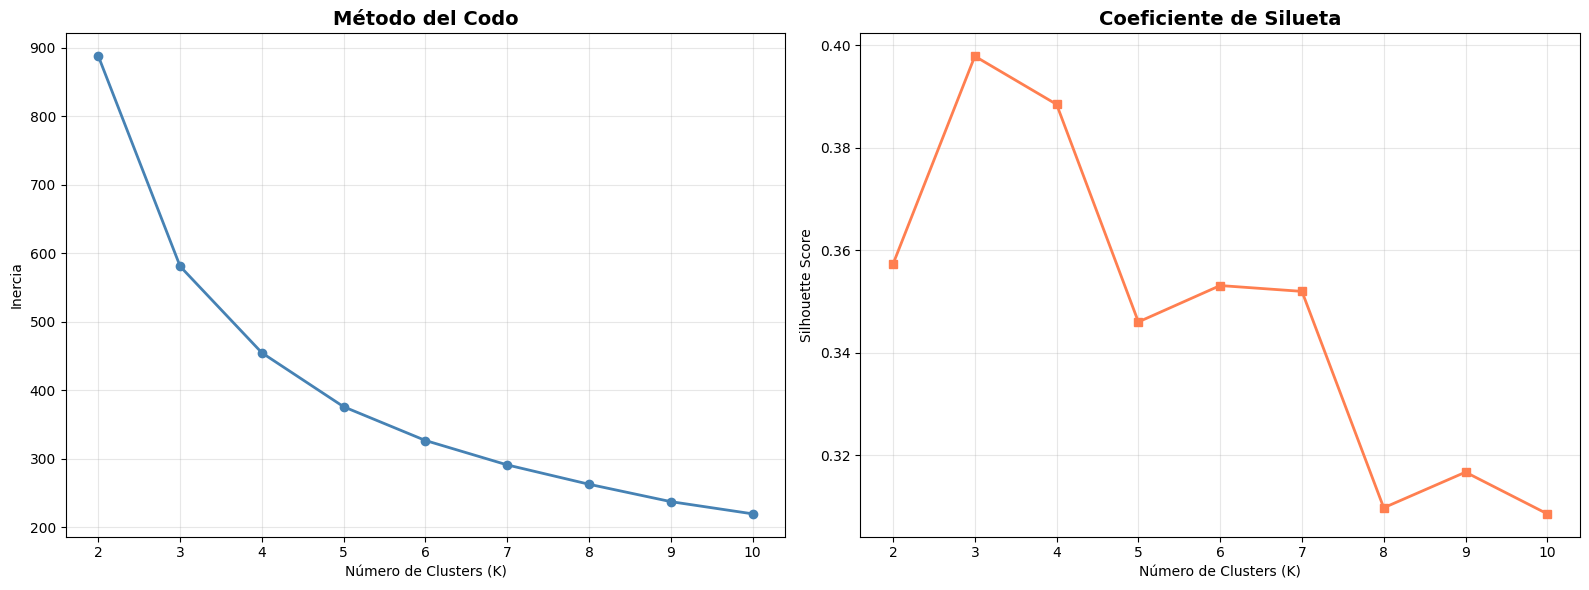


📋 Resumen de resultados:
  K |      Inercia |  Silueta
------------------------------
  2 |       887.82 |   0.3573
  3 |       581.03 |   0.3978
  4 |       454.76 |   0.3884
  5 |       376.03 |   0.3460
  6 |       326.79 |   0.3531
  7 |       291.16 |   0.3520
  8 |       262.92 |   0.3098
  9 |       237.56 |   0.3167
 10 |       219.74 |   0.3086


In [7]:
# Evaluamos de 2 a 10 clusters
rango_k = range(2, 11)
inercias = []
siluetas = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(X_scaled, kmeans.labels_))

# Graficamos el Método del Codo y Silueta juntos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico del Codo
ax1.plot(rango_k, inercias, marker='o', color='steelblue', linewidth=2)
ax1.set_title('Método del Codo', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia')
ax1.set_xticks(range(2, 11))
ax1.grid(True, alpha=0.3)

# Gráfico de Silueta
ax2.plot(rango_k, siluetas, marker='s', color='coral', linewidth=2)
ax2.set_title('Coeficiente de Silueta', fontsize=14, fontweight='bold')
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(range(2, 11))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen
print("\n📋 Resumen de resultados:")
print(f"{'K':>3} | {'Inercia':>12} | {'Silueta':>8}")
print("-" * 30)
for k, iner, sil in zip(rango_k, inercias, siluetas):
    print(f"{k:>3} | {iner:>12,.2f} | {sil:>8.4f}")


## Segmentacion

In [8]:
# Aplicamos KMeans con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters


# Veamos cuántos clientes hay en cada grupo
print("Distribución de clientes por cluster:")
print(df['cluster'].value_counts().sort_index())
df_escalados = pd.DataFrame(X_scaled, columns=['frecuencia','ticket_promedio','cl_value'])
df_escalados['cluster'] = clusters

Distribución de clientes por cluster:
cluster
0    249
1    103
2    114
Name: count, dtype: int64


C:\Users\practicanteit3\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


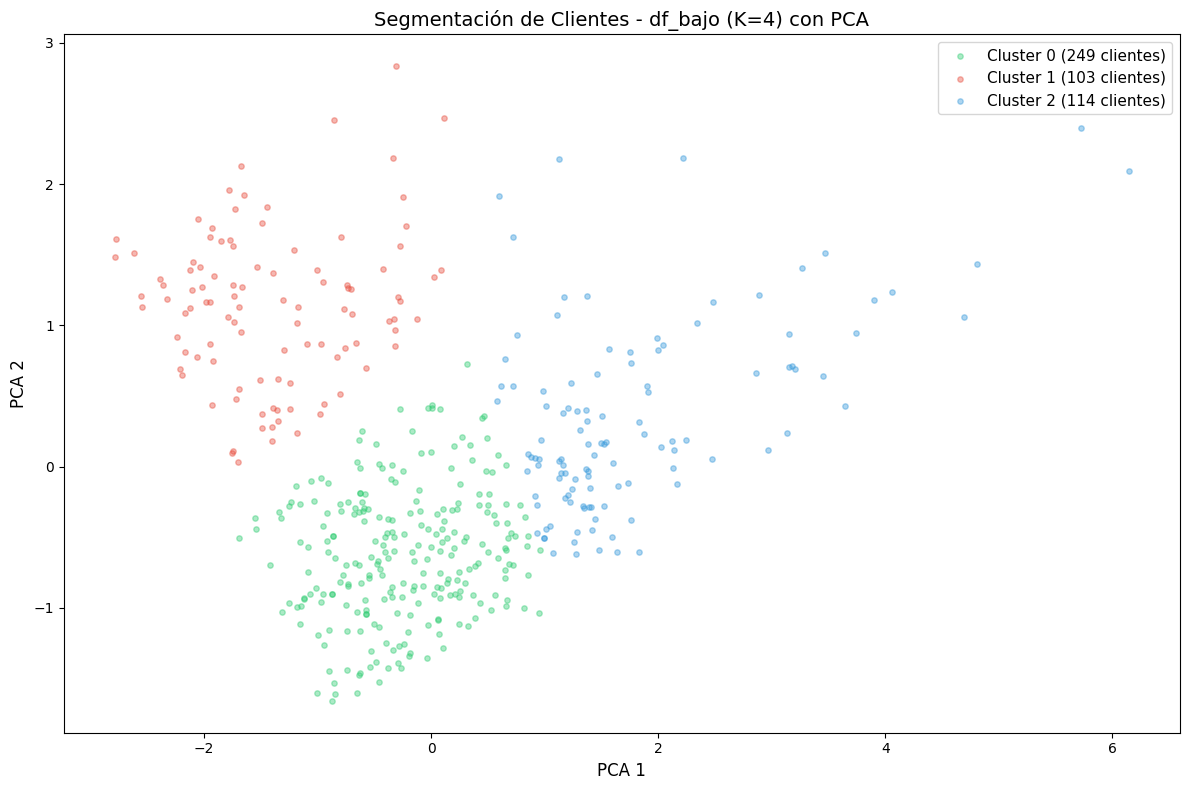

,frecuencia,ticket_promedio,cl_value
0,0.65,0.60,-0.47
1,0.16,0.50,0.85


In [9]:
from sklearn.decomposition import PCA

df = df.reset_index(drop=True)
df_escalados = df_escalados.reset_index(drop=True)

df_escalados = df_escalados.drop(columns=['pca1', 'pca2'], errors='ignore')

pca = PCA(n_components=2)

# ✅ Las 3 variables CORRECTAS sin repetir
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))

colores = ['#2ecc71', '#e74c3c', '#3498db']
nombres = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for cluster in range(3):
    mask = df['cluster'] == cluster
    ax.scatter(df.loc[mask, 'pca1'],
               df.loc[mask, 'pca2'],
               c=colores[cluster],
               label=f'{nombres[cluster]} ({mask.sum():,} clientes)',
               alpha=0.4,
               s=15)

ax.set_xlabel('PCA 1', fontsize=12)
ax.set_ylabel('PCA 2', fontsize=12)
ax.set_title('Segmentación de Clientes - df_bajo (K=4) con PCA', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
info = pca.components_

info = pd.DataFrame(info, columns = ['frecuencia', 'ticket_promedio','cl_value'])
info

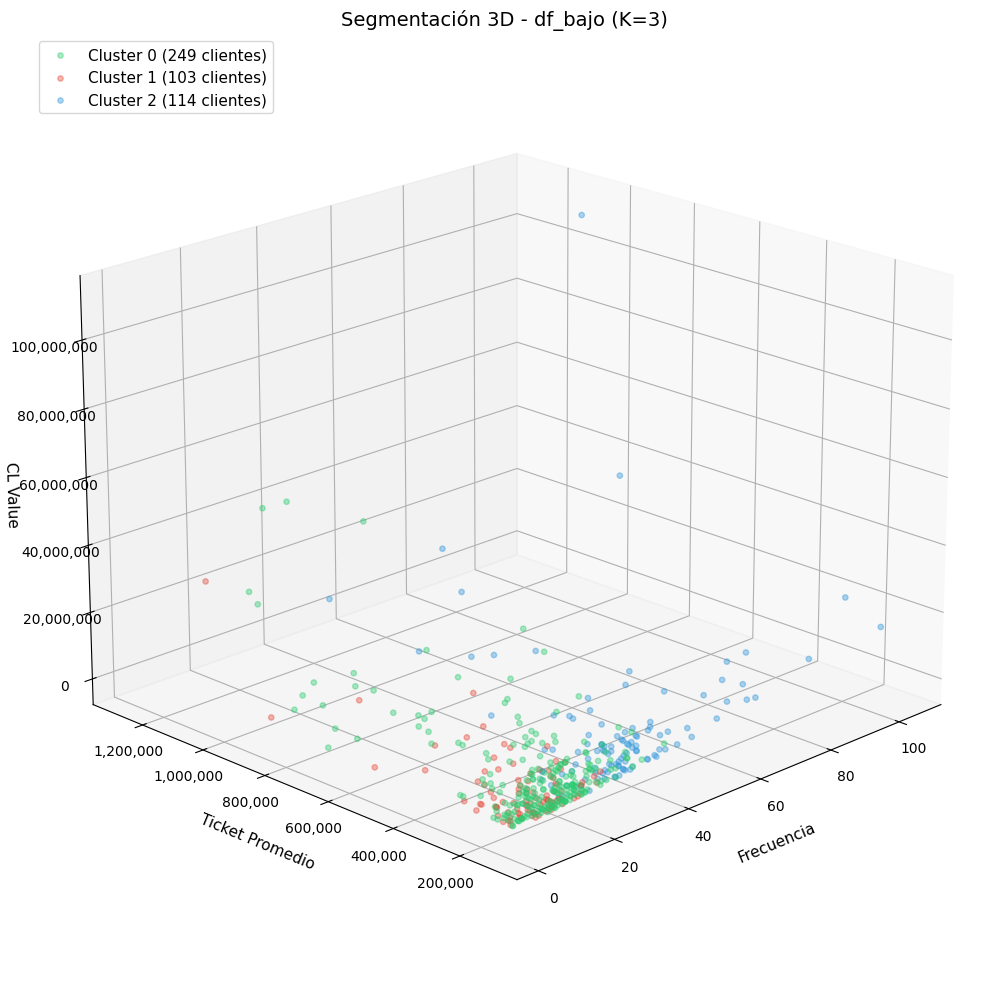

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

pca1=PCA(n_components=3)

X_pca1 = pca1.fit_transform(df[['frecuencia','ticket_promedio','cl_value']])


fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colores = ['#2ecc71', '#e74c3c', '#3498db','#3412f1']
nombres = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for cluster in range(3):
    mask = df['cluster'] == cluster
    ax.scatter(df.loc[mask, 'frecuencia'],
               df.loc[mask, 'ticket_promedio'],
               df.loc[mask, 'cl_value'],
               c=colores[cluster],
               label=f'{nombres[cluster]} ({mask.sum():,} clientes)',
               alpha=0.4,
               s=15)

ax.set_xlabel('Frecuencia', fontsize=11, labelpad=10)
ax.set_ylabel('Ticket Promedio', fontsize=11, labelpad=10)
ax.set_zlabel('CL Value', fontsize=11, labelpad=10)
ax.set_title('Segmentación 3D - df_bajo (K=3)', fontsize=14)

# Formato de números con comas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.zaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax.legend(fontsize=11, loc='upper left')

# Ángulo de visualización
ax.view_init(elev=25, azim=45)

plt.tight_layout()
# Agrega esta línea ANTES de plt.show()

# Ángulo 1: Vista elevada
ax.view_init(elev=30, azim=45)

# Ángulo 2: Vista lateral
ax.view_init(elev=15, azim=120)

# Ángulo 3: Vista frontal
ax.view_init(elev=0, azim=0)

# Ángulo 4: Vista de pájaro (desde arriba)
ax.view_init(elev=90, azim=0)

# Ángulo 5: Vista diagonal
ax.view_init(elev=20, azim=225)

plt.show()

## Barras de segmentos

,frecuencia,ticket_promedio,cl_value
count,3.00,3.00,3.00
mean,22.44,"234,229.06","5,529,504.02"
std,13.73,"14,213.67","3,304,791.51"
min,12.24,"225,150.70","2,821,388.47"
25%,14.63,"226,038.82","3,688,298.44"
50%,17.02,"226,926.95","4,555,208.40"
75%,27.53,"238,768.23","6,883,561.80"
max,38.05,"250,609.52","9,211,915.20"


,frecuencia,ticket_promedio,cl_value
cluster,,,
0,17.02,"250,609.52","4,555,208.40"
1,12.24,"225,150.70","2,821,388.47"
2,38.05,"226,926.95","9,211,915.20"


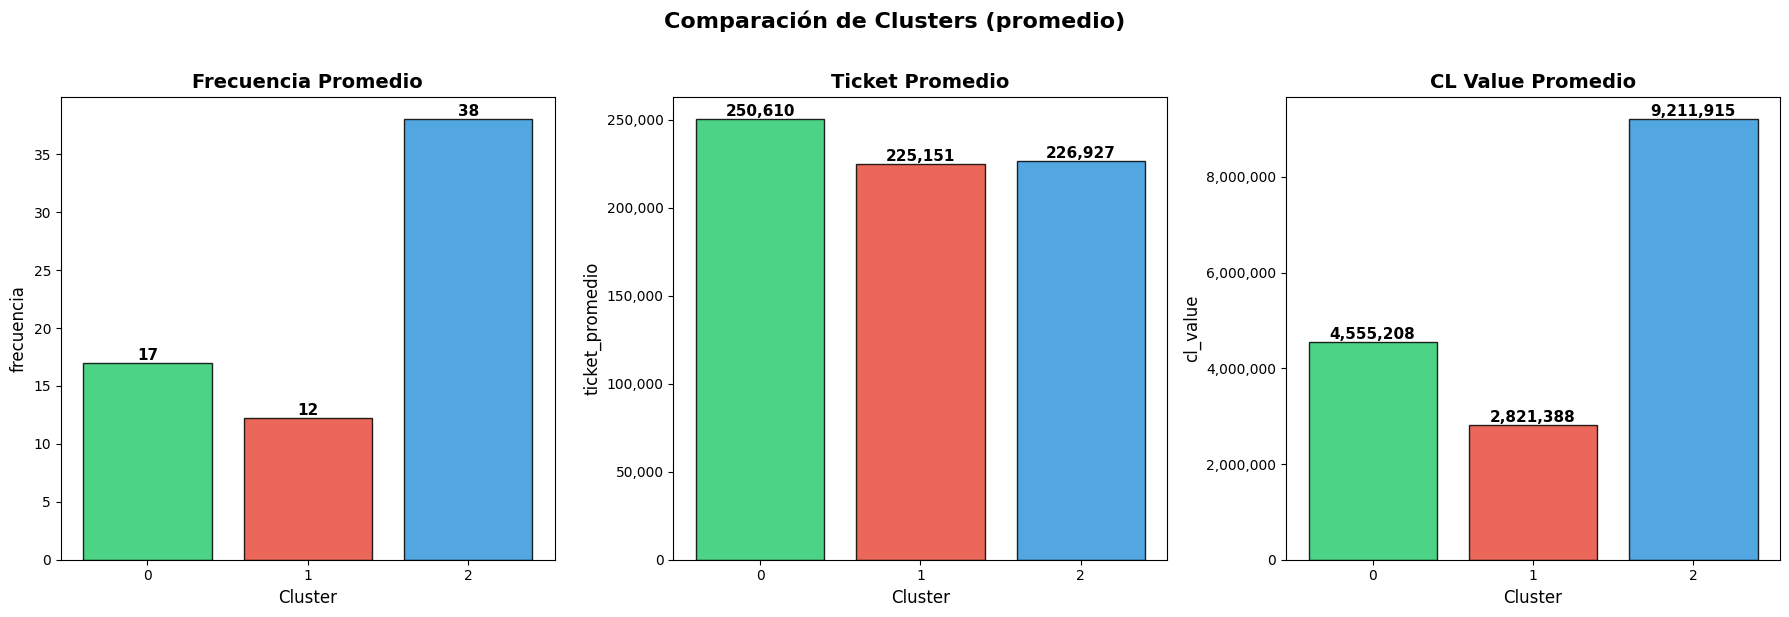

In [11]:
# Calcular promedios por cluster
resumen = df.groupby('cluster')[['frecuencia', 'ticket_promedio', 'cl_value']].mean()
suma = df.groupby('cluster')['cl_value'].sum()

display(resumen.describe())
display(resumen)


# Crear el barplot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colores = ['#2ecc71', '#e74c3c', '#3498db']
variables = ['frecuencia', 'ticket_promedio', 'cl_value']
titulos = ['Frecuencia Promedio', 'Ticket Promedio', 'CL Value Promedio', 'CLV Value Total']

for i, (var, titulo) in enumerate(zip(variables, titulos)):
    bars = axes[i].bar(
        resumen.index.astype(str),
        resumen[var],
        color=colores,
        edgecolor='black',
        alpha=0.85
    )
    
    # Agregar valores encima de cada barra
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2.,
            height,
            f'{height:,.0f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )
    
    axes[i].set_title(titulo, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Cluster', fontsize=12)
    axes[i].set_ylabel(var, fontsize=12)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Comparación de Clusters (promedio)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Segundo grafico

#resumen2 = df.groupby('cluster')[['frecuencia', 'ticket_promedio', 'cl_value']].sum()

#fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#variables2 = ['frecuencia', 'ticket_promedio', 'cl_value']
#titulos2 = ['Frecuencia', 'Ticket', 'CL Value']

#for i, (var, titulo) in enumerate(zip(variables2, titulos2)):
#    bars = axes[i].bar(
#        resumen2.index.astype(str),
#        resumen2[var],
#        color=colores,
#        edgecolor='black',
#        alpha=0.85
#    )
    
    # Agregar valores encima de cada barra
#    for bar in bars:
#        height = bar.get_height()
#        axes[i].text(
#            bar.get_x() + bar.get_width() / 2.,
#            height,
#            f'{height:,.0f}',
#            ha='center',
#            va='bottom',
#           fontsize=11,
#            fontweight='bold'
#        )
    
#    axes[i].set_title(titulo, fontsize=14, fontweight='bold')
#    axes[i].set_xlabel('Cluster', fontsize=12)
#    axes[i].set_ylabel(var, fontsize=12)
#    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

#plt.suptitle('Comparación de Clusters (suma)', fontsize=16, fontweight='bold', y=1.02)
#plt.tight_layout()
#plt.show()

In [12]:
df.head()

,cliente,frecuencia,recencia,ticket_promedio,ticket,referencias_unicas,margen_promeido,margen,avg_descuento,cl_value,linea_favorita,marca_favorita,cluster,pca1,pca2
0,1592227,15,16,"185,303.44","5,003,192.99",9,"120,291.87","3,247,880.48",0.00,"2,779,551.66",MANGANESO,TRONEX,0,-0.32,-0.59
1,3358229,10,3,"310,117.69","4,031,529.99",4,"177,183.74","2,303,388.63",0.08,"3,101,176.92",MANGANESO,TRONEX,0,-0.54,-1.42
2,3364232,7,51,"118,953.76","1,070,583.87",5,"63,831.05","574,479.48",0.01,"832,676.34",BOMBILLAS,SB,1,-1.69,0.55
3,3365883,15,59,"134,605.40","6,057,243.12",14,"74,874.77","3,369,364.53",0.02,"2,019,081.04",MANGANESO,TRONEX,1,-1.00,1.39
4,3370696,7,9,"129,747.23","1,556,966.74",8,"74,147.21","889,766.56",0.00,"908,230.60",MANGANESO,TRONEX,0,-0.57,-1.01


## Analisis de canasta de compra

In [13]:
df_mba = pd.merge(df_historial, df, on='cliente', how = 'inner')
df_mba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38408 entries, 0 to 38407
Data columns (total 45 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   factura              38408 non-null  object 
 1   cliente              38408 non-null  int64  
 2   nombrecliente        38408 non-null  object 
 3   tipocliente          38408 non-null  object 
 4   fechafactura         38408 non-null  object 
 5   referencia           38408 non-null  object 
 6   nombrereferencia     38408 non-null  object 
 7   cantidad             38408 non-null  float64
 8   preciounitario       38408 non-null  float64
 9   costounitario        38408 non-null  float64
 10  montoventa           38408 non-null  float64
 11  montoventapesos      38408 non-null  float64
 12  costoventapesos      38408 non-null  float64
 13  valordescuento       38408 non-null  float64
 14  unidadnegocios       38408 non-null  int64  
 15  centrocostos         38408 non-null 

In [14]:
df_mba.head()

,factura,cliente,nombrecliente,tipocliente,fechafactura,referencia,nombrereferencia,cantidad,preciounitario,costounitario,...,referencias_unicas,margen_promeido,margen,avg_descuento,cl_value,linea_favorita,marca_favorita,cluster,pca1,pca2
0,HHME001298717,70830747,JUAN DAVID CASTAÑO GOMEZ,TAT CENTRO,2025-01-16 00:00:00.000,ALC013654-12,ALPINO COLORES BORRABLES X12,30.00,"14,621.85","5,413.89",...,21,"75,297.89","2,936,617.70",0.00,"1,940,945.32",MANGANESO,TRONEX,1,-0.42,1.40
1,HHME001172359,8300655,LUIS DARIO CUARTAS HERRERA,TAT CENTRO,2024-05-16 00:00:00.000,ALC013654-12,ALPINO COLORES BORRABLES X12,2.00,"13,907.56","5,413.89",...,32,"90,101.69","10,631,998.95",0.06,"5,126,237.36",OTROS,TRONEX,2,1.76,0.74
2,HHME001215545,1005682820,YEISON JOSE JIMENEZ MERCADO,TAT CENTRO,2024-08-05 00:00:00.000,ALC013654-12,ALPINO COLORES BORRABLES X12,6.00,"13,907.56","5,413.89",...,36,"94,989.98","9,688,977.71",0.01,"2,646,918.10",OTROS,TRONEX,2,0.60,1.92
3,HHME001351871,71992360,FRANCISCO EMILIO OSPINA FLOREZ,TAT CENTRO,2025-04-28 00:00:00.000,ALC013654-12,ALPINO COLORES BORRABLES X12,15.00,"14,621.85","5,413.89",...,45,"65,391.90","10,528,095.52",0.11,"4,777,047.94",ENCENDEDORES,TRONEX,2,2.89,1.22
4,HHME001542029,901539604,MUNDIAL DE GAS Y AGUA S.A.S,TAT CENTRO,2026-03-27 00:00:00.000,GP1604AU-C1,PILA ALCALINA GP ULTRA 9V BLISTER X1,10.00,"8,067.23","2,984.08",...,10,"151,188.26","6,349,907.05",0.03,"4,551,217.81",ALKALINAS,TRONEX,0,-0.11,-0.55


In [15]:
basket = df_mba.groupby('factura')['referencia'].apply(list)
indices = basket.index.tolist()

In [16]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori,association_rules

te = TransactionEncoder()
te_ary = te.fit(basket).transform(basket)
df_mba_analysis = pd.DataFrame(te_ary,columns = te.columns_, index = indices )



In [17]:
df_mba_analysis = apriori(df_mba_analysis, min_support= 0.1, use_colnames=True)
df_mba_analysis['productos'] = df_mba_analysis['itemsets'].apply( lambda x: len(x)) 
df_mba_analysis.sort_values(by='support', ascending=False)

,support,itemsets,productos
6,0.39,(TRAAR6EHDR1),1
4,0.32,(TRAALR6ALB2),1
7,0.32,(TRDR20RJBLK180),1
1,0.21,(TRAAALR03ALB2),1
3,0.20,(TRAAAR03EHDBLK),1
5,0.17,(TRAAR6EHDB2),1
11,0.17,"(TRAALR6ALB2, TRAAALR03ALB2)",2
13,0.17,"(TRAAR6EHDR1, TRAAAR03EHDBLK)",2
16,0.15,"(TRDR20RJBLK180, TRAAR6EHDR1)",2
2,0.13,(TRAAAR03EHDB2),1


In [18]:
reglas = association_rules(df_mba_analysis,metric='confidence', min_threshold=0.5)

In [19]:
reglas[(reglas['antecedents'].apply(len)==1) & (reglas['consequents'].apply(len)==1)]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(TRAALR6ALB2),(TRAAALR03ALB2),0.32,0.21,0.17,0.53,2.51,1.00,0.10,1.68,0.89,0.47,0.40,0.67
1,(TRAAALR03ALB2),(TRAALR6ALB2),0.21,0.32,0.17,0.81,2.51,1.00,0.10,3.50,0.76,0.47,0.71,0.67
2,(TRAAR6EHDB2),(TRAAAR03EHDB2),0.17,0.13,0.11,0.62,4.82,1.00,0.09,2.30,0.96,0.56,0.57,0.73
3,(TRAAAR03EHDB2),(TRAAR6EHDB2),0.13,0.17,0.11,0.84,4.82,1.00,0.09,5.19,0.91,0.56,0.81,0.73
4,(TRAAAR03EHDBLK),(TRAAR6EHDR1),0.20,0.39,0.17,0.84,2.16,1.00,0.09,3.82,0.67,0.40,0.74,0.63
5,(TRAAR6EHDB2),(TRAALR6ALB2),0.17,0.32,0.10,0.59,1.84,1.00,0.05,1.65,0.55,0.26,0.39,0.45


In [20]:
reglas[reglas['antecedents']== frozenset({'TRAALR6ALB2'})]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(TRAALR6ALB2),(TRAAALR03ALB2),0.32,0.21,0.17,0.53,2.51,1.00,0.10,1.68,0.89,0.47,0.40,0.67


In [21]:
reglas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   antecedents         6 non-null      object 
 1   consequents         6 non-null      object 
 2   antecedent support  6 non-null      float64
 3   consequent support  6 non-null      float64
 4   support             6 non-null      float64
 5   confidence          6 non-null      float64
 6   lift                6 non-null      float64
 7   representativity    6 non-null      float64
 8   leverage            6 non-null      float64
 9   conviction          6 non-null      float64
 10  zhangs_metric       6 non-null      float64
 11  jaccard             6 non-null      float64
 12  certainty           6 non-null      float64
 13  kulczynski          6 non-null      float64
dtypes: float64(12), object(2)
memory usage: 804.0+ bytes


In [22]:
df_mba.to_parquet('../reglas/segmento_Vip_premium/Basket.parquet')
reglas.to_csv('../reglas/segmento_Vip_premium/reglas.csv',sep=';')